# Fixed Hyperparameters Benchmark

Run all algorithms with manually chosen hyperparameters and visualize the results.

1. Configure the DAG, data generator, and hyperparameters below
2. Run all cells

In [1]:
import sys; sys.path.insert(0, "..")
%load_ext autoreload
%autoreload 2

from pipeline.Benchmark import Benchmark
import pyagrum as gum

/home/mathis/Documents/Travail/cbnsl_benchmark/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
def dag_20vars():
    dag = gum.DAG()
    dag.addNodes(20)
    for t, h in [
        (1, 0), (0, 2), (2, 3), (1, 3), (3, 4), (4, 5), (4, 6), (5, 7),
        (6, 7), (6, 8), (9, 8), (2, 9), (11, 7), (0, 15), (9, 10), (12, 10),
        (12, 11), (16, 15), (14, 15), (16, 14), (13, 12), (14, 13), (13, 17),
        (16, 17), (17, 18), (18, 19),
    ]:
        dag.addArc(t, h)
    return dag

In [3]:
bench = Benchmark.synthetic_cbn(dag_20vars(), n_samples=1000, marginal_type="Uniform", lcc_types="NormalCopula")

In [4]:
configs = {
    "CPC":           {"alpha": 0.05, "max_conditioning_set_size": 2},
    "CMIIC":         {"alpha": 0.01},
    "MIIC":          {"n_bins": 2, "discretization_method": "quantile"},
    "GHC+BDeu":      {"n_bins": 4, "discretization_method": "quantile"},
    "NOTEARS":       {"lambda1": 0., "w_threshold_notears": 0.3},
    "NOTEARS Disc.": {"lambda1": 0.1, "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "quantile"},
    "LiNGAM":        {"threshold_lingam": 0.075},
}

## Run

In [5]:
bench.run_fixed(configs)

  CPC: OK
  CMIIC: OK
  MIIC: OK
  GHC+BDeu: OK
  NOTEARS: OK
  NOTEARS Disc.: OK
  LiNGAM: OK
Done.



Benchmark(dataset='cbn_Uniform_NormalCopula__20vars_1000s', 7 algorithms)

## Golden structure

Golden CPDAG: 19 arcs, 7 edges


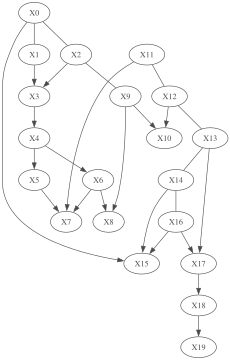

In [6]:
bench.show_golden()

## Best scores (CPDAG)

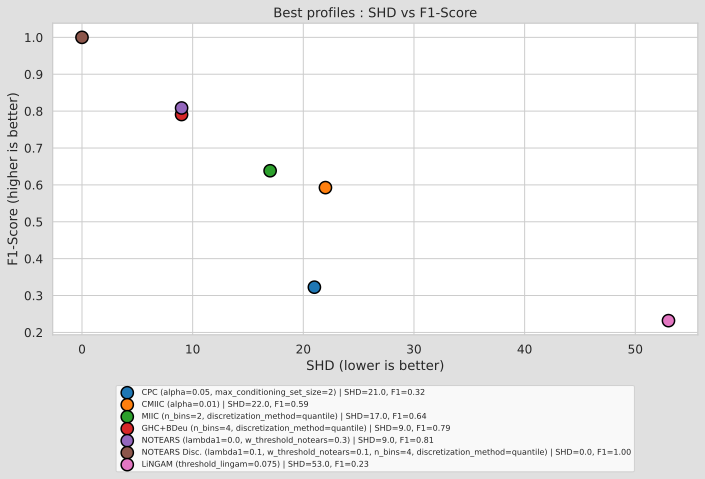

In [7]:
bench.plot_best_scores("cpdag")

## Best scores (Skeleton)

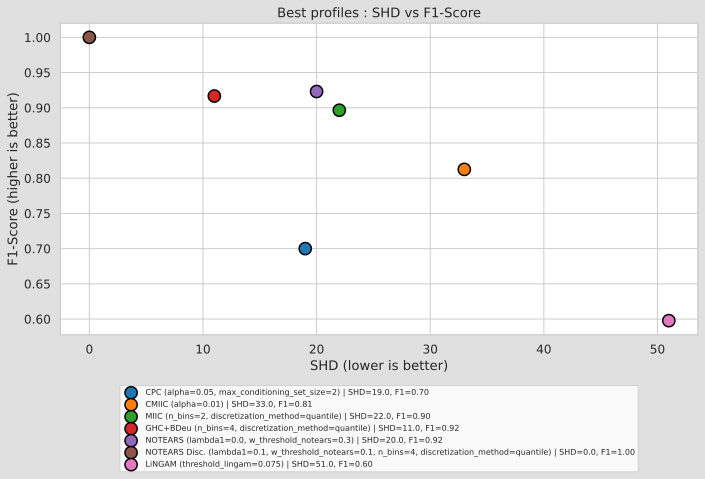

In [8]:
bench.plot_best_scores("skeleton")

## Learned structures

In [9]:
bench.plot_structures()

## Pairwise heatmaps (CPDAG)

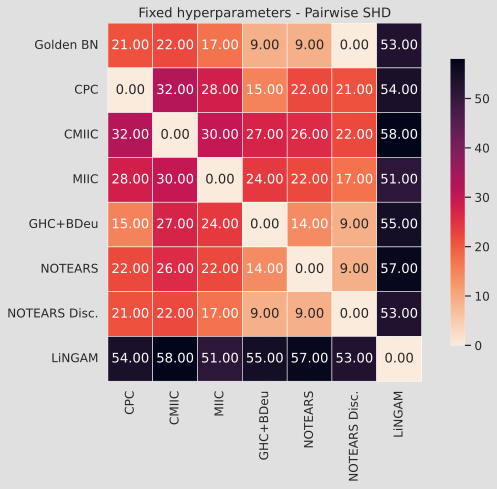

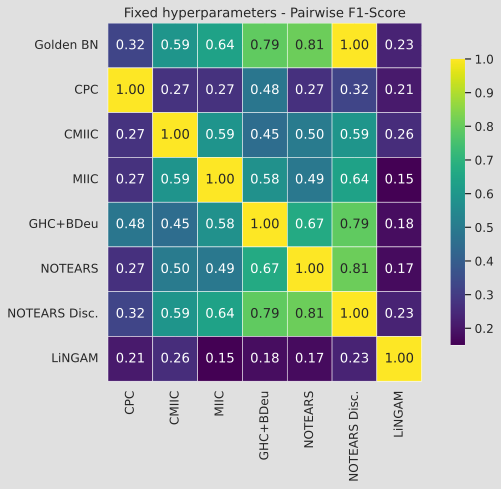

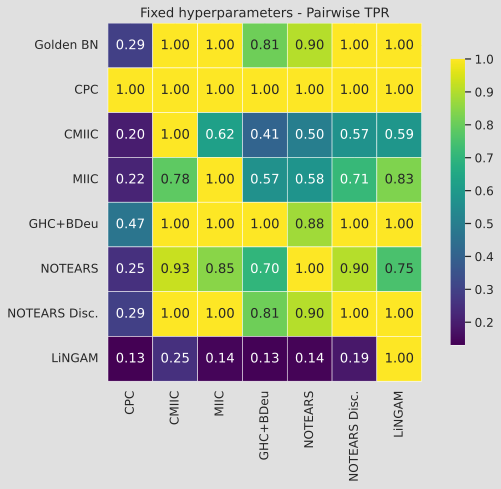

In [10]:
bench.plot_pairwise_heatmaps("cpdag")

## Pairwise heatmaps (Skeleton)

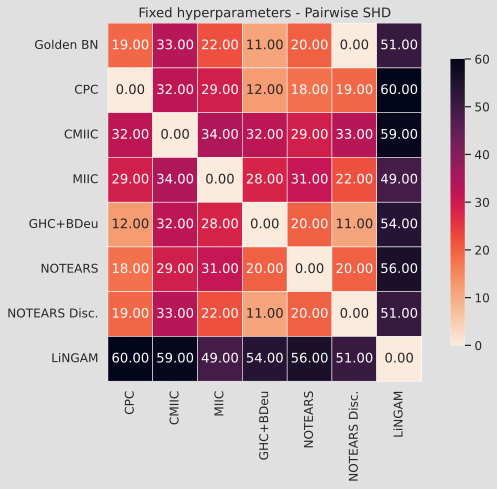

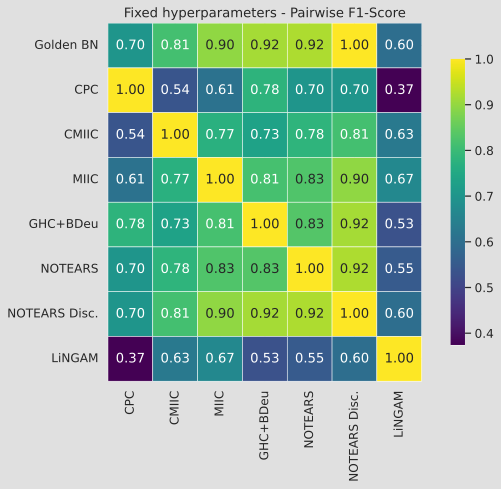

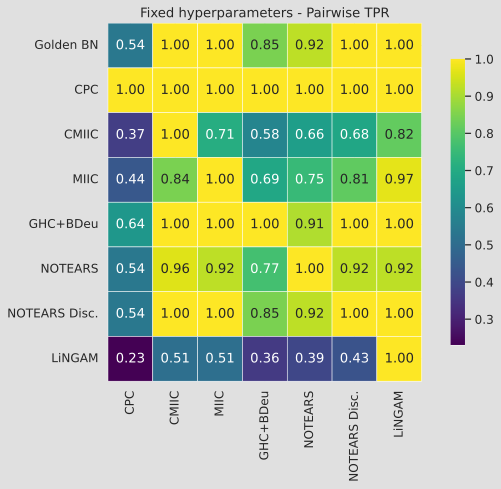

In [11]:
bench.plot_pairwise_heatmaps("skeleton")

In [12]:
!jupyter nbconvert --to html ./visualize_fixed.ipynb

[NbConvertApp] Converting notebook ./visualize_fixed.ipynb to html
[NbConvertApp] Writing 297157 bytes to visualize_fixed.html
